# Numpy
the core of many tools,powerful arrays as a data structure
## the resorce C code:
```C
struct _longobject {
    long ob_refcnt;
    PyTypeObject *ob_type;
    size_t ob_size;
    long ob_digit[1];
};
```

In [2]:
import numpy as np

### create arrays

In [8]:
print(np.array([1,2,3],dtype='float32'))
print(np.array([range(i,i+3) for i in [2,4,6]]))
print(np.zeros((10,5),dtype=int))
print(np.ones((2,3)))
print(np.full(2,3),9)
print(np.arange(0,20,2)) #from 0 to 20,every 2 steps,default as for 0 to n every step
print(np.linspace(0,1,5)) #from 0 to 1, 5 numbers

[1. 2. 3.]
[[2 3 4]
 [4 5 6]
 [6 7 8]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
[[1. 1. 1.]
 [1. 1. 1.]]
[3 3] 9
[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


1. actually,we transform a kind of data structure into array.
2. we use an array for the size,'dtype' for the data type.
3. as for arange,linspace: it only come as form of a vector,need to be reshape to a certain structure

### random number

In [9]:
np.random.seed(42) # a start for recurrence
print(np.random.randint(10,size=(2,3))) # generate natural number from 0 to 10,in size of (2,3)
print(np.random.random((2,3))) # generate any 0<=x<=1 
print(np.random.normal(0,1,(3,3))) # normal distribution average 0,variance 1

[[6 3 7]
 [4 6 9]]
[[0.15599452 0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449]]
[[-0.58087813 -0.52516981 -0.57138017]
 [-0.92408284 -2.61254901  0.95036968]
 [ 0.81644508 -1.523876   -0.42804606]]


### index
very similar to normal data structure,use : to describe the 

In [10]:
x=np.arange(10)
print(x[:5])
print(x[5:])
print(x[3::2])
print(x[3:-1])
print(x[::-1]) #reverse the array
y=x.reshape((2,5)) #change the arrange of the data
print(y[1,:])
print(y[0])
y1=y[:1,:1]
y1[0,0]=1
print(y) # it represent a kind of copy, change the origin one
# Fancy indexing:use array as index
x=np.arange(10)
i=np.array([2,1,4])
x[i]-=2
print(x)

[0 1 2 3 4]
[5 6 7 8 9]
[3 5 7 9]
[3 4 5 6 7 8]
[9 8 7 6 5 4 3 2 1 0]
[5 6 7 8 9]
[0 1 2 3 4]
[[1 1 2 3 4]
 [5 6 7 8 9]]
[ 0 -1  0  3  2  5  6  7  8  9]


### operation among arraies

In [11]:
z=x[::-1]
print(np.vstack([x,z]))
print(np.hstack([x,z]))
x1,x2,x3=np.split(x,[3,5])
print(x1,x2,x3)
x1,x2,x3=np.hsplit(x,[3,5])
print(x1,x2,x3)
# assemble and split the specific array,generally we use v(vehicle),h(horizontal) to describe the way we operate the array.

[[ 0 -1  0  3  2  5  6  7  8  9]
 [ 9  8  7  6  5  2  3  0 -1  0]]
[ 0 -1  0  3  2  5  6  7  8  9  9  8  7  6  5  2  3  0 -1  0]
[ 0 -1  0] [3 2] [5 6 7 8 9]
[ 0 -1  0] [3 2] [5 6 7 8 9]


### caulculation
UFuncs:vectorized operation(we automatically transform number or vector to matrix for data analysis,simplify the loop)

In [12]:
print("x+2=",x+2)
print("|x-5|=",abs(x-5))
# more kinds of functions: exp,log,trigo(specific funcs need special )
print("exp(x)=",np.expm1(x),"tan(x)=",np.tan(x),"log2(x+1)=",np.log(x+1))
# specifying output
z=np.zeros(20)
np.multiply(x,10,out=z[::2])
# aggregates (reture the result)
x=np.arange(6)
print(np.add.reduce(x))
print(np.add.accumulate(x))
# outer products (can be used for vector)
print(np.multiply.outer(x,x))

x+2= [ 2  1  2  5  4  7  8  9 10 11]
|x-5|= [5 6 5 2 3 0 1 2 3 4]
exp(x)= [ 0.00000000e+00 -6.32120559e-01  0.00000000e+00  1.90855369e+01
  6.38905610e+00  1.47413159e+02  4.02428793e+02  1.09563316e+03
  2.97995799e+03  8.10208393e+03] tan(x)= [ 0.         -1.55740772  0.         -0.14254654 -2.18503986 -3.38051501
 -0.29100619  0.87144798 -6.79971146 -0.45231566] log2(x+1)= [0.               -inf 0.         1.38629436 1.09861229 1.79175947
 1.94591015 2.07944154 2.19722458 2.30258509]
15
[ 0  1  3  6 10 15]
[[ 0  0  0  0  0  0]
 [ 0  1  2  3  4  5]
 [ 0  2  4  6  8 10]
 [ 0  3  6  9 12 15]
 [ 0  4  8 12 16 20]
 [ 0  5 10 15 20 25]]


C:\Users\bytt\AppData\Local\Temp\ipykernel_8324\2213413907.py:4: RuntimeWarning: divide by zero encountered in log
  print("exp(x)=",np.expm1(x),"tan(x)=",np.tan(x),"log2(x+1)=",np.log(x+1))


### Aggregations
some statistic values for data

In [19]:
print(np.sum(x))
print(np.min(x),np.max(x))
print(x[np.newaxis,:].max(axis=1))

15
1 5
[5]


some useful aggregation funcs
| 函数名称      |   NaN安全版本  | 说明                                   |
|-------------------|---------------------|-----------------------------------------------|
| ``np.sum``        | ``np.nansum``       | 计算总和                       |
| ``np.prod``       | ``np.nanprod``      | 计算乘积                   |
| ``np.mean``       | ``np.nanmean``      | 计算平均值                      |
| ``np.std``        | ``np.nanstd``       | 计算标准差                    |
| ``np.var``        | ``np.nanvar``       | 计算方差                              |
| ``np.min``        | ``np.nanmin``       | 计算最小值                            |
| ``np.max``        | ``np.nanmax``       | 计算最大值                            |
| ``np.argmin``     | ``np.nanargmin``    | 寻找最小值的序号                   |
| ``np.argmax``     | ``np.nanargmax``    | 寻找最大值的序号                   |
| ``np.median``     | ``np.nanmedian``    | 计算中位值                    |
| ``np.percentile`` | ``np.nanpercentile``| 计算百分比分布的对应值     |
| ``np.any``        | N/A                 | 是否含有True值        |
| ``np.all``        | N/A                 | 是否全为True值        |


### broadcast
the extension of normal
rule:
1. if 2 array have different dimensions, the one with fewer will expend on its left size with 1.  
((1,1),3 $\to$ (1,1),(1,3))
2. if the 2 doesn't match, the 1 in the dimension will stretch to match the other  
((1,1),(1,3) $\to$ ((1,3) $\times 2$ ))
3. if the operation above failed, than will generate a false   
(2,4 $\to$ false)  
some explain:we can see it geometrically, 2 dimension is a kind of 3 with 1 in the first dimension.

In [16]:
x=np.arange(3)
y=x.reshape((3,1))
print(x+y)
# a way to expand : newaxis(add 1 dimension to place needed),
z=np.hstack([y,y])
x[:,np.newaxis]+z

[[0 1 2]
 [1 2 3]
 [2 3 4]]


array([[0, 0],
       [2, 2],
       [4, 4]])

In [17]:
#boolen logic: the further utility of broadcast,return boolen array
print(x==3)
# usually we use funcs to demonstrate the situation of boolen value
print(np.sum(x==3),np.any(x<=3))
print(np.any(x>1)&np.all(x<4))
# moreover: to give out all the values that fit the requirement
print(x[x>1])

[False False False]
0 True
True
[2]


### sorting
provide different sorting criteria, depend on different needs
we use normal sort for change,argsort for find the index

In [22]:
x = np.array([2, 1, 4, 3, 5])
print(np.sort(x)) # return result
i=np.argsort(x) #return index
print(i,x[i[1]],x[i[4]])
print(np.partition(x,2)) #only need to separate into 2 part, the smaller 2 in the left
y=np.random.randint(0,10,(4,6))
print(np.sort(y,axis=0))
print(np.sort(y,axis=1))
print(np.partition(y,2,axis=1))

[1 2 3 4 5]
[1 0 3 2 4] 2 5
[1 2 3 4 5]
[[0 1 1 1 3 1]
 [5 3 4 3 4 1]
 [8 5 9 3 5 6]
 [9 7 9 7 7 7]]
[[0 1 1 3 3 7]
 [1 3 5 5 5 9]
 [1 3 6 7 9 9]
 [1 4 4 7 7 8]]
[[0 1 1 7 3 3]
 [1 3 5 9 5 5]
 [1 3 6 9 7 9]
 [1 4 4 8 7 7]]


### Structured array
similar to panda's dataframe, work as multiply data form

In [23]:
data = np.zeros(4, dtype={'names':('name', 'age', 'weight'),
                          'formats':('U10', 'i4', 'f8')}) #create with 
print(data.dtype)
name = ['Alice', 'Bob', 'Cathy', 'Doug']
age = [25, 45, 37, 19]
weight = [55.0, 85.5, 68.0, 61.5]
data['name'] = name
data['age'] = age
data['weight'] = weight
print(data)
# referring to specific data
print(data['name'])
print(data[-1]['age'])
print(data[data['age']<30]['name'])

[('name', '<U10'), ('age', '<i4'), ('weight', '<f8')]
[('Alice', 25, 55. ) ('Bob', 45, 85.5) ('Cathy', 37, 68. )
 ('Doug', 19, 61.5)]
['Alice' 'Bob' 'Cathy' 'Doug']
19
['Alice' 'Doug']


## summary for Numpy
Numpy is a kind of library that can be used to initially process data.   
To be brief, Numpy has the ability as followed:   
1. create random array
2. use broadcast to operate array, connect or split it.
3. use funcs to do feature work, find out the sum,min,max or so.
4. use index to find out the specific data(fancy indexing)
5. use sort,partition to arrange the array
6. use dictionary-like arrays to restore data(can be easily replaced by pandas)

# Pandas
provide DataFrame, more friendly to sheet that are more common in normal research  

In [3]:
import pandas as pd

### create and visit

In [25]:
#Series
# normal Series:index or value
data = pd.Series([0.25, 0.5, 0.75, 1.0])
print(data.values,data[1:3])
data = pd.Series([0.25, 0.5, 0.75, 1.0],
                 index=['a', 'b', 'c', 'd'])
print(data)
# similar to dictionary
grade={'a':100,'b':99,'c':99}
g=pd.Series(grade)
print(g['a'],g['a':'c'])
# create :index,dictionary
print(pd.Series(grade,index=['a','c']))
# the Series can be seen as dict, with key and only one value.index determine the order

[0.25 0.5  0.75 1.  ] 1    0.50
2    0.75
dtype: float64
a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64
100 a    100
b     99
c     99
dtype: int64
a    100
c     99
dtype: int64


In [26]:
# DataFrame
# the combination of Series 
num={'a':'1','b':2,'c':3}
sub=pd.DataFrame({'grade':g,'number':pd.Series(num)})
print(sub,sub.index,sub.columns,sub['grade'])
# a special dict object
data = [{'a': i, 'b': 2 * i}
        for i in range(3)]
print(pd.DataFrame(data))
# straightly from 2 dimensions numpy
pd.DataFrame(np.random.rand(3, 2),
             columns=['foo', 'bar'],
             index=['a', 'b', 'c'])

   grade number
a    100      1
b     99      2
c     99      3 Index(['a', 'b', 'c'], dtype='object') Index(['grade', 'number'], dtype='object') a    100
b     99
c     99
Name: grade, dtype: int64
   a  b
0  0  0
1  1  2
2  2  4


,foo,bar
a,0.356753,0.280935
b,0.542696,0.140924
c,0.802197,0.074551


In [ ]:
#index: unalterable,repetitive,usually represent the object(columns represent the feature), just the order of data.
ind=pd.Index([2,1,2])
# we don't use it usually

### indexing
we usually use loc,iloc to index the specific place(remember index is a kind of harsh list, the index often refers to that kind of thing)

In [34]:
data = pd.Series(['a', 'b', 'c'], index=[1, 3, 5])
data1 = pd.Series(['a', 'b', 'c'])
print(data,data1)
print(data[1],data[1:3])
print(data1[1],data1[1:3])
# index is harsh things, if you don't say the index,it will be default 0-n
print(sub['grade'],sub.grade,sub['grade'] is sub.grade)
# loc refers to explicit index(the name of index), iloc refers to implicit index(the number\place of the index)
print(data.iloc[1:3]) #the correspond order(the second to the fourth)
print(data.loc[1:3]) #the value of index (1-3)
# moreover we can use boolen logic to choose the data
print(sub.loc[sub.grade>99,['number']]) 

1    a
3    b
5    c
dtype: object 0    a
1    b
2    c
dtype: object
a 3    b
5    c
dtype: object
b 1    b
2    c
dtype: object
a    100
b     99
c     99
Name: grade, dtype: int64 a    100
b     99
c     99
Name: grade, dtype: int64 True
3    b
5    c
dtype: object
1    a
3    b
dtype: object
  number
a      1


### operation
similar to Numpy,but keep the index and column, and automatically aligns the labels  
and we should pay attention to the NaN values,that may make undefined operation

In [ ]:
rng=np.random.RandomState(42)
df = pd.DataFrame(rng.randint(0, 10, (3, 4)),
                  columns=['A', 'B', 'C', 'D'])
print(np.sin(df * np.pi / 4))
# index alignment:the operation guarantee the alignment of index,so need to see if the index is correpond,or need to deal with the NaN values
area = pd.Series({'bj':400,'gz':300},name='area')
population=pd.Series({'bj':1000,'shh':300},name='population')
print(population / area )
a=pd.Series(np.arange(3),index=[0,1,2])
b=pd.Series(np.arange(3),index=[1,2,3])
print(a+b)
print(a.add(b,fill_value=0))
# as for operation between Series and DataFrame, we use broadcast as well
print(df-df.loc[0],df-df.loc[0][0]) # careful we have to use .loc for pd

          A             B         C             D
0 -1.000000  7.071068e-01 -0.707107  1.224647e-16
1 -1.000000  7.071068e-01  1.000000 -1.000000e+00
2 -0.707107  1.224647e-16  0.707107 -7.071068e-01
bj     2.5
gz     NaN
shh    NaN
dtype: float64
0    NaN
1    1.0
2    3.0
3    NaN
dtype: float64
0    0.0
1    1.0
2    3.0
3    2.0
dtype: float64
   A  B  C  D
0  0  0  0  0
1  0  6 -5  2
2  1  1 -4  3    A  B  C  D
0  0 -3  1 -2
1  0  3 -4  0
2  1 -2 -3  1


C:\Users\bytt\AppData\Local\Temp\ipykernel_8324\2485050000.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df-df.loc[0],df-df.loc[0][0])


In [ ]:
# deal with missing data:none&nan,nan is the most used,the operation return nan rather than false(in pandas, we can use NA to represent better one)
print(1+np.nan)
val=pd.Series([1,np.nan,2])
print(np.sum(val)) # already changed to nansum
df.iloc[0,0]=np.nan
print(df.isnull())
print(df.dropna())
print(df.dropna(axis='columns'))
print(df.dropna(how='all'))
print(df.dropna(how='any'))
print(df.fillna(0))
print(df.fillna(method='ffill'),df.fillna(method='bfill'))

nan
3.0
       A      B      C      D     0
0   True  False  False  False  True
1  False  False  False  False  True
2  False  False  False  False  True
Empty DataFrame
Columns: [A, B, C, D, 0]
Index: []
   B  C  D
0  3  7  4
1  9  2  6
2  4  3  7
     A  B  C  D   0
0  NaN  3  7  4 NaN
1  6.0  9  2  6 NaN
2  7.0  4  3  7 NaN
Empty DataFrame
Columns: [A, B, C, D, 0]
Index: []


operation for nan:  
> - ``isnull()``: Generate a boolean mask indicating missing values
> - ``notnull()``: Opposite of ``isnull()``
> - ``dropna()``: Return a filtered version of the data(delete all the nan value and keep the square form),we can use how,thread to deal with it
> - ``fillna()``: Return a copy of the data with missing values filled or imputed

### Multiply indexing
for those with more than 1 key for each feather, we can use multiIndex to handle it.

In [12]:
import numpy as np
import pandas as pd
index=[('a',1),('b',1),('a',2),('b',2),('a',3),('b',3)]
value=[100,200,300,400,500,600]
p=pd.Series(value,index=index)
print(p)
index=pd.MultiIndex.from_tuples(index) #every value is a tuple
p=p.reindex(index)
print(p)
print(p[:,3]) # use double index to index the value
# also we can change it to DataFrame
pdf=p.unstack()
print(pdf)
print(pdf.stack())
# from Series to DataFrame
print(pd.DataFrame({'value':p,'more':[1,2,3,4,5,6]}))
# creating multiply index
# have to show all the 
index=[['a','b','a','b'],[1,1,2,2]] # isn't out multiply have to print one by one
print(pd.DataFrame(np.random.rand(4,2),index=index,columns=['q','w'])) 
data = {('California', 2000): 33871648,
        ('California', 2010): 37253956,
        ('Texas', 2000): 20851820,
        ('Texas', 2010): 25145561,
        ('New York', 2000): 18976457,
        ('New York', 2010): 19378102}
print(pd.Series(data))
# pay attention to the difference,usually the func will lead to depart of index, transform from class will lead to combination
# for stright muliply index
print(pd.MultiIndex.from_arrays([['a', 'a', 'b', 'b'], [1, 2, 1, 2]]))
#print(pd.MultiIndex.from_tuples([('a', 1), ('a', 2), ('b', 1), ('b', 2)]))
#print(pd.MultiIndex.from_product([['a', 'b'], [1, 2]]))
#for the same result
print(pd.MultiIndex(levels=[['a', 'b'], [1, 2]],
              codes=[[0, 0, 1, 1], [0, 1, 0, 1]]))
# multiindex for columns : construct multiindex and use the func to construct the DataFrame
index = pd.MultiIndex.from_product([[2013, 2014], [1, 2]],
                                   names=['year', 'visit'])
columns = pd.MultiIndex.from_product([['Bob', 'Guido', 'Sue'], ['HR', 'Temp']],
                                     names=['subject', 'type'])
data = np.round(np.random.randn(4, 6), 1)
h= pd.DataFrame(data, index=index, columns=columns)
print(h)
# index for multiply:iloc,loc 
print(h.iloc[:4,:4])
print(h.loc[1:,'Bob':])
idx=pd.IndexSlice
print(h.loc[idx[:,1],idx[:,'HR']]) # as for multiply index, we have to use slice to descibe the mutual relationship. 

(a, 1)    100
(b, 1)    200
(a, 2)    300
(b, 2)    400
(a, 3)    500
(b, 3)    600
dtype: int64
a  1    100
b  1    200
a  2    300
b  2    400
a  3    500
b  3    600
dtype: int64
a    500
b    600
dtype: int64
     1    2    3
a  100  300  500
b  200  400  600
a  1    100
   2    300
   3    500
b  1    200
   2    400
   3    600
dtype: int64
     value  more
a 1    100     1
b 1    200     2
a 2    300     3
b 2    400     4
a 3    500     5
b 3    600     6
            q         w
a 1  0.415769  0.047997
b 1  0.500207  0.026323
a 2  0.393275  0.204906
b 2  0.510420  0.443167
California  2000    33871648
            2010    37253956
Texas       2000    20851820
            2010    25145561
New York    2000    18976457
            2010    19378102
dtype: int64
MultiIndex([('a', 1),
            ('a', 2),
            ('b', 1),
            ('b', 2)],
           )
MultiIndex([('a', 1),
            ('a', 2),
            ('b', 1),
            ('b', 2)],
           )
subject     Bob      

In [15]:
#index processing
index = pd.MultiIndex.from_product([['a', 'c', 'b'], [1, 2]])
p = pd.Series(np.random.rand(6), index=index)
p.index.names = ['char', 'int']
print(p)
# usually the key dont have the order,require sort
p=p.sort_index()
print(p['a':'b'])
# a useful way to get transform a Series to DataFrame
p=p.reset_index(name='value')
print(p) #release every layers, get rid of multiindex
print(p.set_index(['char','int'])) #return a DataFrame with only one column(able to freely add columns flexibly)

char  int
a     1      0.813743
      2      0.070197
c     1      0.828859
      2      0.303445
b     1      0.017750
      2      0.024431
dtype: float64
char  int
a     1      0.813743
      2      0.070197
b     1      0.017750
      2      0.024431
dtype: float64
  char  int     value
0    a    1  0.813743
1    a    2  0.070197
2    b    1  0.017750
3    b    2  0.024431
4    c    1  0.828859
5    c    2  0.303445
             value
char int          
a    1    0.813743
     2    0.070197
b    1    0.017750
     2    0.024431
c    1    0.828859
     2    0.303445


### connection
a proper way for dealing with complex dataset     
the synax of `concat`
```python
# Pandas v0.24.2's Function signature
pd.concat(
    objs,
    axis=0,
    join='outer',  
    join_axes=None,
    ignore_index=False,  # ignore the index and reset it in order
    keys=None,
    levels=None,
    names=None,
    verify_integrity=False,  # if there is repetitive index return error
    sort=None,
    copy=True,
)
```
merge: a powerful tool to merge DataFrame: able to deal with one-to-one,one-to-many,many-to-many   
only if we keep the index aligned(the same index or the index of column)

In [11]:
import numpy as np
import pandas as pd
# concat
a=pd.DataFrame(np.arange(1,9).reshape((2,4)))
b=pd.DataFrame(np.arange(9,17).reshape((2,4)))
print(pd.concat([a,b])) # careful it dont change the index
print(pd.concat([a,b],ignore_index=True)) # rearange the data
print(pd.concat([a, b], keys=['A', 'B'])) # add index of the resource
a_diff = pd.DataFrame({'A': [1,2], 'B': [3,4]})
b_diff = pd.DataFrame({'B': [5,6], 'C': [7,8]})
print(pd.concat([a_diff, b_diff]))
print(pd.concat([a_diff, b_diff], join='inner')) # define if is union set or intersection

    0   1   2   3
0   1   2   3   4
1   5   6   7   8
0   9  10  11  12
1  13  14  15  16
    0   1   2   3
0   1   2   3   4
1   5   6   7   8
2   9  10  11  12
3  13  14  15  16
      0   1   2   3
A 0   1   2   3   4
  1   5   6   7   8
B 0   9  10  11  12
  1  13  14  15  16
     A  B    C
0  1.0  3  NaN
1  2.0  4  NaN
0  NaN  5  7.0
1  NaN  6  8.0
   B
0  3
1  4
0  5
1  6


In [4]:
#merge
import numpy as np
import pandas as pd
data=pd.DataFrame({'p':['a','a','b','b','c','c'],'j':['q','q','q','q','p','p'],'v':[1,1,2,2,3,4]})
print(data)
job=data[['p','j']].drop_duplicates(subset=['p'])
value=data[['p','v']].drop_duplicates(subset=['p'])
print(pd.merge(job,value))# one-to-one need the same key to be not duplicate or will work as many to many and do outer multiply
print(pd.merge(job,data[['j','v']].drop_duplicates(subset=['j']))) # one-to-many outer multiply
print(pd.merge(job,data[['j','v']].drop_duplicates(subset=['v']))) # many-to-many 

   p  j  v
0  a  q  1
1  a  q  1
2  b  q  2
3  b  q  2
4  c  p  3
5  c  p  4
   p  j  v
0  a  q  1
1  b  q  2
2  c  p  3
   p  j  v
0  a  q  1
1  b  q  1
2  c  p  3
   p  j  v
0  a  q  1
1  a  q  2
2  b  q  1
3  b  q  2
4  c  p  3
5  c  p  4


In [8]:
#specifying the methods: deal with overlapping situations
# on: determine the aligned column
print(pd.merge(job,value,on='p'))# for those have more than 1 same columns and aligned by the specified column. if have the same name of column,have to add suffix to it
print(pd.merge(job,job,on="p",suffixes=["_L","_R"]))
# set_index:choose the column as index
print(job.set_index('p'))
# determine how to merge
a=pd.DataFrame({'a':[1,2,3],'b':[3,4,5]})
b=pd.DataFrame({'a':[1,4],'c':[8,9]})
print(pd.merge(a,b)) # default as inner
print(pd.merge(a,b,how='outer')) 
print(pd.merge(a,b,how='left')) # use the index of the left one(include every data of the left data)

   p  j  v
0  a  q  1
1  b  q  2
2  c  p  3
   p j_L j_R
0  a   q   q
1  b   q   q
2  c   p   p
   j
p   
a  q
b  q
c  p
   a  b  c
0  1  3  8
   a    b    c
0  1  3.0  8.0
1  2  4.0  NaN
2  3  5.0  NaN
3  4  NaN  9.0
   a  b    c
0  1  3  8.0
1  2  4  NaN
2  3  5  NaN


### Groupby : Split,Apply,Combine
1. Split: breaking up and grouping a DataFrame depending on the value of the specified key.
2. Apply: use some functions to aggregate the splited DataFrame into data required
3. combine: merge all the result above    
actually, we use groupby as a special object, with many convenient operations,make it more convenient to get the operate on specified columns
split: use new index to access the Data(any kind of form of index)
1. Align: see if `len(L)==len(data)`
2. Map: go through `L` , and use `L[i]` as `Group Label`
3. split: divide all row with the same `L[i]` into one group
4. Apply: go through functions     
use the provided `L` as index correlated to the data(take the place of `range(n)`)
use dictionary key:value,use value as the new key to split

In [ ]:
q=['a','b','c','a','b','c']
data=pd.DataFrame({'o':q,'v':range(6),'s':np.arange(6)*100})
print(data)
# split: 
# create the groupby object: use ()to find the sign,and [] to operate, thus we get the object. then we can apply
print(data.groupby('o')['v'].describe())
# feature work:we get the feature of 'o',find the element of 'o',and the size of it
# we divide the DataFrame on 'o': method: the name of the group;group just group. group.shape:the size of it
# so we get the different value of'o',and the size of it
for (method,group) in data.groupby('o'):
    print("{0:30s} shape={1}".format(method,group.shape))
#specify split key: we can use any kind of data form(include the )

   o  v    s
0  a  0    0
1  b  1  100
2  c  2  200
3  a  3  300
4  b  4  400
5  c  5  500
   count  mean      std  min   25%  50%   75%  max
o                                                 
a    2.0   1.5  2.12132  0.0  0.75  1.5  2.25  3.0
b    2.0   2.5  2.12132  1.0  1.75  2.5  3.25  4.0
c    2.0   3.5  2.12132  2.0  2.75  3.5  4.25  5.0
a                              shape=(2, 3)
b                              shape=(2, 3)
c                              shape=(2, 3)


In [34]:
#apply
# aggregation: use the specified form of data to display
print(data.groupby('o').agg(['min','median','max']))
print(data.groupby('o').agg({'v':'min','s':'max'}))
# filtering : need a func to define the rule of filter(filter the returned one)
print(data.groupby('o').filter(lambda x:x['s'].std()>4))
# transform : need a func to define the rule
print(data.groupby('o').transform(lambda x:x-x.mean()))
# apply()
def f(x):
    x['v']/=x['s'].sum()
    return x
print(data.groupby('o').apply(f, include_groups=False))

    v               s            
  min median max  min median  max
o                                
a   0    1.5   3    0  150.0  300
b   1    2.5   4  100  250.0  400
c   2    3.5   5  200  350.0  500
   v    s
o        
a  0  300
b  1  400
c  2  500
   o  v    s
0  a  0    0
1  b  1  100
2  c  2  200
3  a  3  300
4  b  4  400
5  c  5  500
     v      s
0 -1.5 -150.0
1 -1.5 -150.0
2 -1.5 -150.0
3  1.5  150.0
4  1.5  150.0
5  1.5  150.0
            v    s
o                 
a 0  0.000000    0
  3  0.010000  300
b 1  0.002000  100
  4  0.008000  400
c 2  0.002857  200
  5  0.007143  500


### Pivot Tables
see the aggregation of the DataFrame in tables' form    
it provide a more precise way to display data    
```python
pd.pivot_table(
    data, # DataFrame，当为方法时，这里是self
    values=None, # the column used as value
    index=None, # the coulmn used as index
    columns=None, # the coulmn used as column
    aggfunc='mean', # how to operate it(dont need value)
    fill_value=None, # the contect to replace nan
    margins=False, # the sum of index and column
    dropna=True, # default drop
    margins_name='All', # decide the name
    observed=False #must use it
)
```

In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
tita=sns.load_dataset('titanic')
tita.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# pivot_table provide a better func for agg
print(tita.groupby(['sex','class'],observed=False)['survived'].agg('mean').unstack())
print(tita.pivot_table('survived',index='sex',columns='class',observed=False))
# muti-level:
age = pd.cut(tita['age'], [0, 18, 80]) # divide it in value
fare = pd.qcut(tita['fare'], 2) #  divide it evenly(according to distribution)
print(tita.pivot_table('survived', ['sex', age], [fare, 'class'],observed=False))
# aggfunc: usually use dict to describe the func(the key as the correspond column the value as the operation)
print(tita.pivot_table(index='sex', columns='class',
                    aggfunc={'survived':sum, 'fare':'mean'}))
# margins : count the sum of data
print(tita.pivot_table('survived', index='sex', columns='class', margins=True))

class      First    Second     Third
sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447
class      First    Second     Third
sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447
class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663
fare            (-0.001, 14.454]                     (14.454, 512.329]  \
class                      First    Second     Third             First   
sex    age                                                               
female (0, 18]               NaN  1.000000  0.714286          0.909091   
       (18, 80]              NaN  0.880000  0.444444          0.972973   
male   (0, 18]               NaN  0.000000  0.260870      

### vectorized String Operations
some method for string operation : `str()`    
the `str` work for every element(string),dont change the shape of dataframe 
function of string:
|             |                  |                  |                  |
|-------------|------------------|------------------|------------------|
|``len()``    | ``lower()``      | ``translate()``  | ``islower()``    | 
|``ljust()``  | ``upper()``      | ``startswith()`` | ``isupper()``    | 
|``rjust()``  | ``find()``       | ``endswith()``   | ``isnumeric()``  | 
|``center()`` | ``rfind()``      | ``isalnum()``    | ``isdecimal()``  | 
|``zfill()``  | ``index()``      | ``isalpha()``    | ``split()``      | 
|``strip()``  | ``rindex()``     | ``isdigit()``    | ``rsplit()``     | 
|``rstrip()`` | ``capitalize()`` | ``isspace()``    | ``partition()``  | 
|``lstrip()`` |  ``swapcase()``  |  ``istitle()``   | ``rpartition()`` |

regular expressions:
| methods | description |
|--------|-------------|
| ``match()`` | use ``re.match()`` for every element,return `Series` |
| ``extract()`` | use ``re.match()`` for every element,return `Series` that match model |
| ``findall()`` | use ``re.findall()`` for every element |
| ``replace()`` | replace those match the model |
| ``contains()`` | use ``re.search()``， for every element,return Series |
| ``count()`` | count the number that match the model |
| ``split()``   | the same as ``str.split()``，but accept regular expressions parameters |
| ``rsplit()`` | the same as ``str.rsplit()``, but accept regular expressions parameters |

function that are miscellaneous:
| methods | description |
|--------|-------------|
| ``get()`` | use index to get string from string |
| ``slice()`` | slice every the string |
| ``slice_replace()`` | replace every slice |
| ``cat()``      | link every element to a string |
| ``repeat()`` | repeat operation to every string element |
| ``normalize()`` | return normal result of string in form of unicode |
| ``pad()`` | align the string |
| ``wrap()`` | new line |
| ``join()`` | link string |
| ``get_dummies()`` | divide the string and construct a dummy DataFrame of 2 dimensions |

more detailed info is omitted

### Time Series
1. Time stamps(Datetime) : the specific time point(used to describe the time), only restore point
2. Time intervals(Period): the interval and the start. better to be used to generate deltas
3. Time deltas(time delta): only restore the interval value

usually we create datetime object

periods(for work form require b in front) 
| code   | description         | code   | description          |
|--------|---------------------|--------|----------------------|
| ``D``  |    normal day    | ``B``  | work day       |
| ``W``  | normal week              |        |                      |
| ``M``  | normal month           | ``BM`` | work month   |
| ``A``  | normal year            | ``BA`` | work year    |
| ``H``  | n hour               | ``BH`` |        work hour |
| ``T``  | min             |        |                      |
| ``S``  | second             |        |                      |
| ``L``  | mms         |        |                      |
| ``U``  | $\mu s$        |        |                      |
| ``N``  | $ns$         |        |                      |
can be mixed use to represent mixed data

In [7]:
import pandas as pd
import numpy as np
# normal python methods 
from datetime import datetime
print(datetime(year=2026,month=7,day=13))
from dateutil import parser
date = parser.parse("13rd of July, 2026")
print(date)
print(date.strftime('%A'))
# datatime64 : a numpy object, easier to process in vector form:
date=np.array('2026-07-13',dtype=np.datetime64)
print(date+np.arange(12))
print(np.datetime64('2015-07-04 12:59:59.50', 'ns'))
# Timestamp：indexing by time
index=pd.DatetimeIndex(date+np.arange(4))
print(pd.Series([0,1,2,3],index=index))
dates=pd.to_datetime([datetime(2026,7,13),'14th of July, 2026','2026-Jul-16', '07-17-2026', '20260718']) # better way to generate index : to_datetime
print(dates)
# interval
dates.to_period('D') # freq='D'
print(dates - dates[0]) # return the interval 
# range:create time vector
print(pd.date_range('2026-07-13', '2026-07-16'))
print(pd.date_range('2026-07-13', periods=4))
print(pd.date_range('2026-07-13', periods=4, freq='h'))

2026-07-13 00:00:00
2026-07-13 00:00:00
Monday
['2026-07-13' '2026-07-14' '2026-07-15' '2026-07-16' '2026-07-17'
 '2026-07-18' '2026-07-19' '2026-07-20' '2026-07-21' '2026-07-22'
 '2026-07-23' '2026-07-24']
2015-07-04T12:59:59.500000000
2026-07-13    0
2026-07-14    1
2026-07-15    2
2026-07-16    3
dtype: int64
DatetimeIndex(['2026-07-13', '2026-07-14', '2026-07-16', '2026-07-17',
               '2026-07-18'],
              dtype='datetime64[ns]', freq=None)
TimedeltaIndex(['0 days', '1 days', '3 days', '4 days', '5 days'], dtype='timedelta64[ns]', freq=None)
DatetimeIndex(['2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16'], dtype='datetime64[ns]', freq='D')
DatetimeIndex(['2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16'], dtype='datetime64[ns]', freq='D')
DatetimeIndex(['2026-07-13 00:00:00', '2026-07-13 01:00:00',
               '2026-07-13 02:00:00', '2026-07-13 03:00:00'],
              dtype='datetime64[ns]', freq='h')


In [10]:
# summary of time: we usually use time as index
# create index
time=pd.to_datetime('2026-07-13')
print(time)
print(time.to_period)
print(time+pd.to_timedelta(np.arange(4),'D'))
print(pd.date_range('2026-07-13',periods=2,freq='h'))
print(pd.period_range('2026-07-13',periods=2,freq='d'))
print(pd.timedelta_range(0, periods=10, freq='h'))

2026-07-13 00:00:00
<bound method _Timestamp.to_period of Timestamp('2026-07-13 00:00:00')>
DatetimeIndex(['2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16'], dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2026-07-13 00:00:00', '2026-07-13 01:00:00'], dtype='datetime64[ns]', freq='h')
PeriodIndex(['2026-07-13', '2026-07-14'], dtype='period[D]')
TimedeltaIndex(['0 days 00:00:00', '0 days 01:00:00', '0 days 02:00:00',
                '0 days 03:00:00', '0 days 04:00:00', '0 days 05:00:00',
                '0 days 06:00:00', '0 days 07:00:00', '0 days 08:00:00',
                '0 days 09:00:00'],
               dtype='timedelta64[ns]', freq='h')


### eval() & query()
use high-performance func to simulate the operation C

In [ ]:
# eval(): use input string to cauculate (return the result of the cauculation)
rng=np.random.RandomState(42)
a,b,c,d=(pd.DataFrame(rng.randint(0,30,(3,5))) for i in range(5)) #a convenient way to repeat
print(np.allclose(-a*b/(c+d),pd.eval('-a*b/(c+d)')))
print(np.allclose(a<b,pd.eval('a<b')))
print(np.allclose((a<0.5)&(b<0.5)|(c<d),pd.eval('(a<0.5)&(b<0.5)|(c<d)')))
print(np.allclose((a<0.5)&(b<0.5)|(c<d),pd.eval('(a<0.5) and (b<0.5) or (c<d)')))
# to sum up,the eval can do anything that return a value
# as for DataFrame we have tailered characteristic
da=pd.DataFrame(rng.rand(4, 3), columns=['A', 'B', 'C'])
# calculation
print(np.allclose(da['A']+da['B'],pd.eval('da.A+da.B')))
print(np.allclose(da['A']+da['B'],da.eval('A+B')))
# operation
da.eval('D=(A+B)/C',inplace=True)
print(da)
# local variation : add @ to demonstrate the local one
j=da.mean(1)
print(np.allclose(da['A']+j,da.eval('A+@j')))

# query() : more like a filter return those satisfy the requirement(return a DataFrame with less index)
print(np.allclose(da[(da.A<0.5)&(da.B)<0.5],da.query('A < 0.5 and B<0.5')))

## summmary for pandas
pandas is a kind of library that can be used to process sheets data in matrix way(kind of similar to matlab)
1. DataFrame: usually,we use index refer objects, and columns refers to features.usually the index is harsh list, default nature number(can be set initially)
2. as for the index, we usually just use the loc(precisely demostrate the place)
3. the opeartion keeps the index aligned, so need to deal with the lack of value(fill_value)  
we can use the specific func can customize on different basis(fill_value,axis),also the broadcast can be used to fix it.  
also there are many func that can be used to handle the stuff.
4. about the operation on index, we can use multiply index for structural input.  
Usually we construct the MultiIndex (tuples,product,array),and use the func(pd.S or D)to build the stuff   
after that, we can name it(more convenient for index),but we the index dont have its order,require sort_index for using :   
as for access data, S:straightly use the name,D: require iloc,loc(require slice for alteral access)
5. operation on merge data:    
as for simply make the index longer(align the column and add more index),only copy and paste. we use concat.   
as for the same kind of object and merge the data(align the specified column),add more feature to the object. we use merge. 
6. group:
we just `groupby` to operate function on specified key.    
split the DataFrame in the order of key,and use specific funcs to display the feature
7. graph:    
show the groupby in form of graph, provide a more precise way than groupby(work on construct a graph rather than an object, thus more easy)
8. time :
usually we just use it to create a time index and some operation to get the data of it.
9. C kind of func :    
used to reduce the consumption of cauculation, deal with large amount of data


# Matplotlib
a powerful visualization tool

### introduction
usually the plot is plotted on either a script or jupyter : for script we use only one `show()` to show all. in IPython, we use `%matplotlib` to draw directly in notebook : 
> - ``%matplotlib notebook`` will lead to *interactive* plots embedded within the notebook
> - ``%matplotlib inline`` will lead to *static* images of your plot embedded in the notebook (more used)    
actually there are 2 interfaces for the price of one:
> - `MATLAB` : use more `.` to describe the feature of plot, more easy to construct
> - `Object-orinted' : use object more precise, a must in complex plot

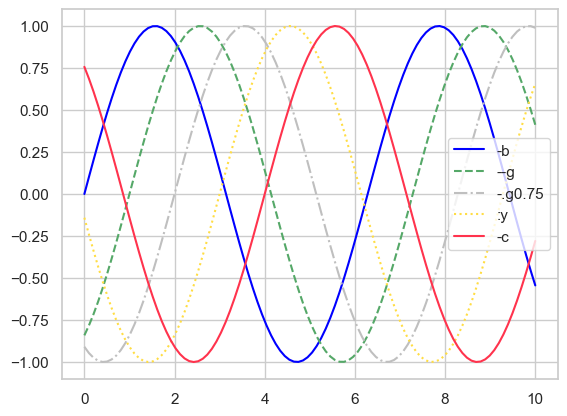

In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
x=np.linspace(0,10,100) # link point with line(require big enough point dataset)
fig=plt.figure()
plt.plot(x, np.sin(x - 0), color='blue',linestyle='solid',label='-b')        # by full name ,also '-'
plt.plot(x, np.sin(x - 1), color='g', linestyle='dashed',label='--g')           # by short form of name(rgbcmyk),also '--'
plt.plot(x, np.sin(x - 2), color='0.75', linestyle='dashdot',label='-.g0.75')        # by grey value between 0~1, also '-.'
plt.plot(x, np.sin(x - 3), color='#FFDD44', linestyle='dotted',label=':y')     # RRGGBB value in 16bit, also ':'
plt.plot(x, np.sin(x - 4), color=(1.0,0.2,0.3),label='-c') # RGB tuple，between 0-1
# also we can use short form: ':r','-g' or so
# fig.savefig('fig.png') # save the image
plt.legend() # show the legend

Text(0, 0.5, 'sin(x)')

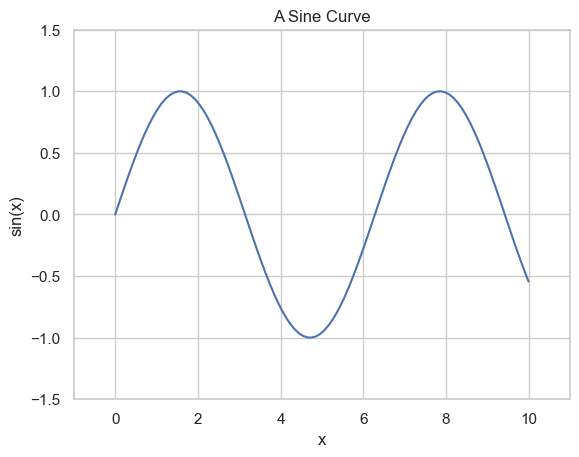

In [8]:
# change the scope of plot
plt.plot(x, np.sin(x))
plt.xlim(-1, 11)
plt.ylim(-1.5, 1.5)
# change the label of it
plt.title("A Sine Curve")
plt.xlabel("x")
plt.ylabel("sin(x)")

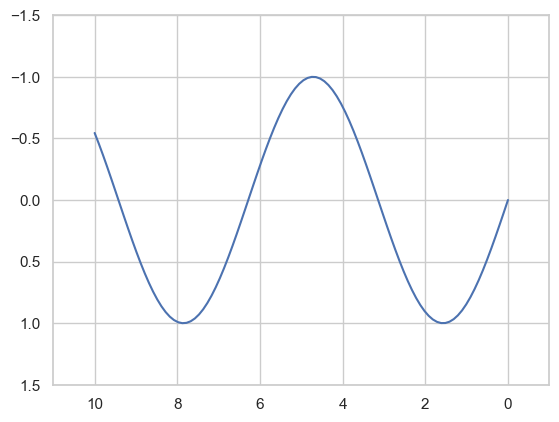

In [ ]:
# we can use axis to define the scale of fig, and we can also reverse the whole fig to show the result
plt.plot(x, np.sin(x))
plt.axis([11, -1, 1.5, -1.5])

(np.float64(-0.5),
 np.float64(10.5),
 np.float64(-1.0993384025373631),
 np.float64(1.0996461858110391))

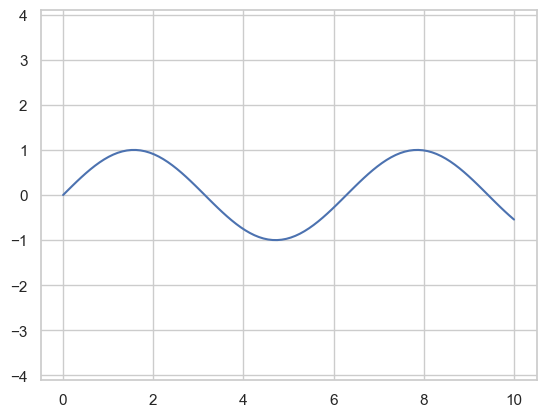

In [ ]:
# also we can just tighten it around the plot,and use equal to set equal 
plt.plot(x, np.sin(x))
plt.axis('tight')
plt.axis('equal')

### scatter
use scatter to show precise data(rather than straight simulation)

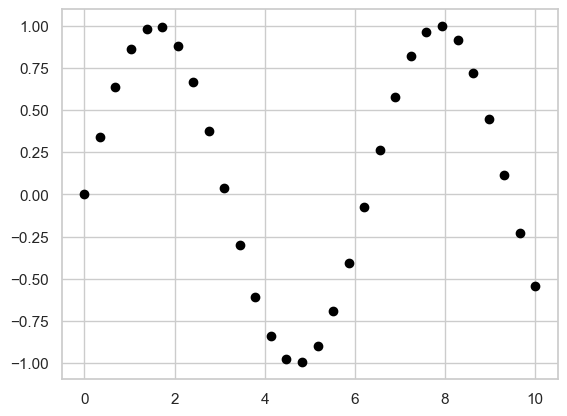

In [9]:
x = np.linspace(0, 10, 30)
plt.plot(x, np.sin(x), 'o', color='black');

(0.0, 1.8)

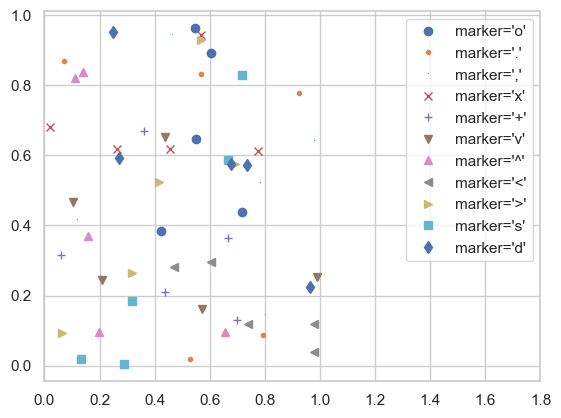

In [ ]:
# different form of point
rng = np.random.RandomState(0)
for marker in ['o', '.', ',', 'x', '+', 'v', '^', '<', '>', 's', 'd']:
    plt.plot(rng.rand(5), rng.rand(5), marker,
             label="marker='{0}'".format(marker))
plt.legend(numpoints=1)
plt.xlim(0, 1.8)

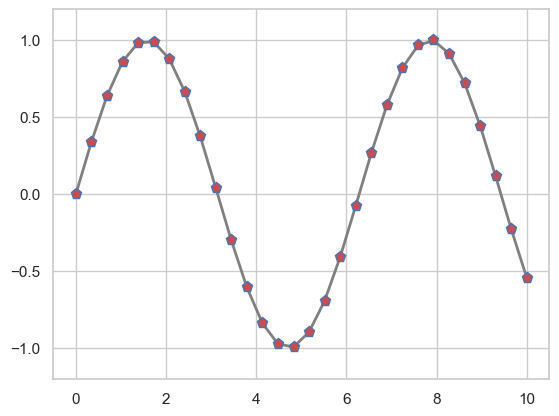

In [12]:
# more properties
plt.plot(x,np.sin(x) , '-p', color='gray',
         markersize=8, linewidth=2,
         markerfacecolor='r',
         markeredgecolor='b',
         markeredgewidth=1)
plt.ylim(-1.2, 1.2);

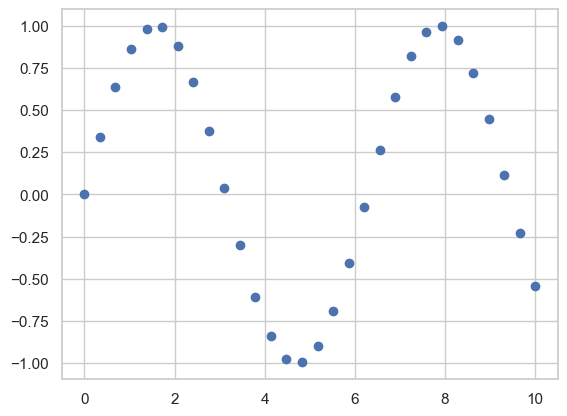

In [ ]:
# a more powerful way: plt.scatter,but take more resource and should be used when the dataset is small
plt.scatter(x, np.sin(x), marker='o')

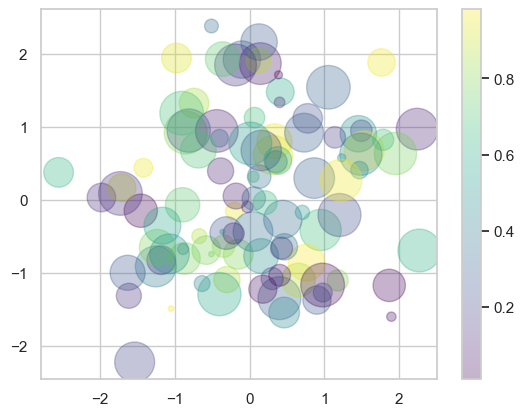

In [14]:
rng = np.random.RandomState(0)
x = rng.randn(100)
y = rng.randn(100)
colors = rng.rand(100)
sizes = 1000 * rng.rand(100)
plt.scatter(x, y, c=colors, s=sizes, alpha=0.3,cmap='viridis') # alpha: transparency,cmap: a kind of mapping scheme that map value to color(this is commonly used)
plt.colorbar(); # similar to legend show the value to color

### visualizing error


<ErrorbarContainer object of 3 artists>

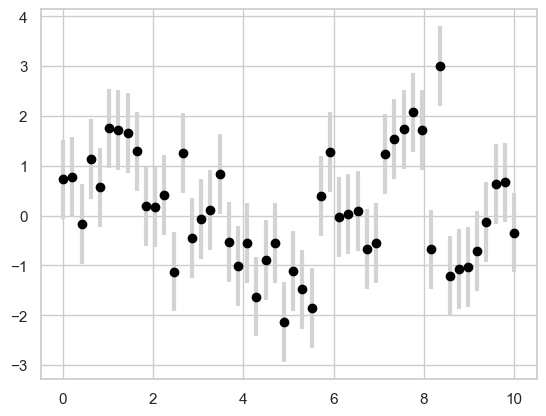

In [24]:
# errorbar
dy=0.8
error=dy*np.random.randn(50) 
x=np.linspace(0,10,50)
y=np.sin(x)
plt.errorbar(x, y+error, yerr=dy, fmt='o', color='black',
             ecolor='lightgray', elinewidth=3, capsize=0)

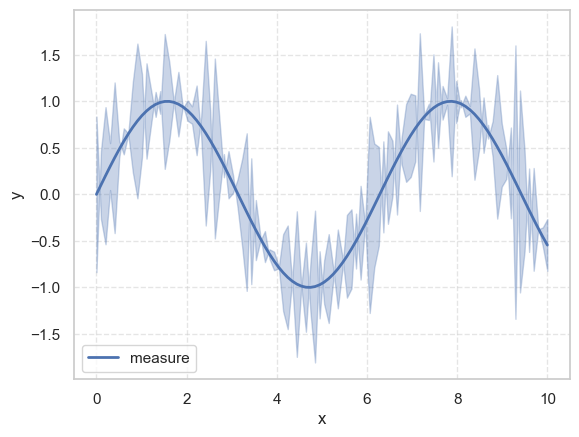

In [28]:
# continuous error (scikit-learn)
plt.plot(x, y, 'b-', linewidth=2, label='measure')
plt.fill_between(x, y - error, y + error, color='b', alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5) 
# usually the continuous

### Density and Contour Plots
a way to show 3-dimensional data in 2-dimensions.
we get 3 different kind of func: `contour()`,`contourf()`,`imshow`

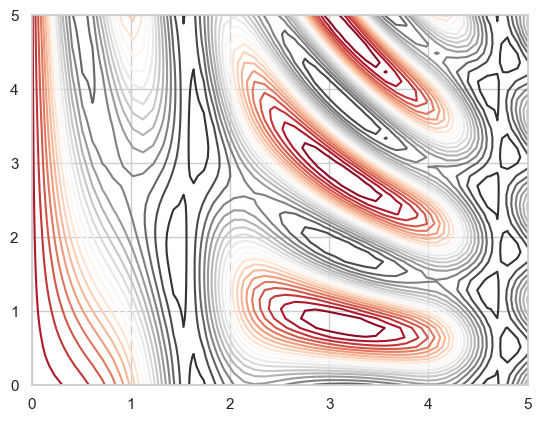

In [ ]:
def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)
x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)
X, Y = np.meshgrid(x, y) # similar to ourter multiply,return coordinates for x,y
Z = f(X, Y)
plt.contour(X, Y, Z, 20, cmap='RdGy') # automatically create 20 value between equally
# usually it will create no more than 7 layers(try to make the result simple)
# also we can stipulate the specific value: plt.contour(X, Y, Z, levels=[-1, 0, 1], cmap=...)

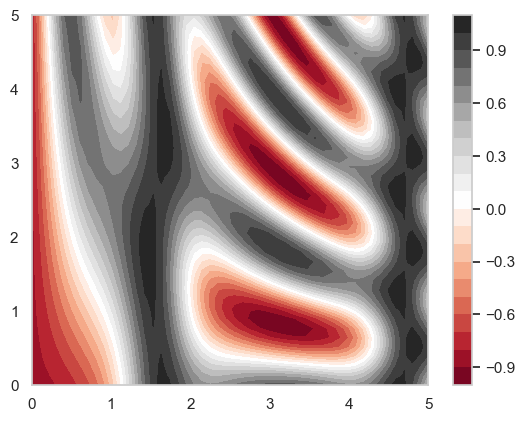

In [32]:
# to show the rough trend, we can just fill it
plt.contourf(X, Y, Z, 20, cmap='RdGy')
plt.colorbar()

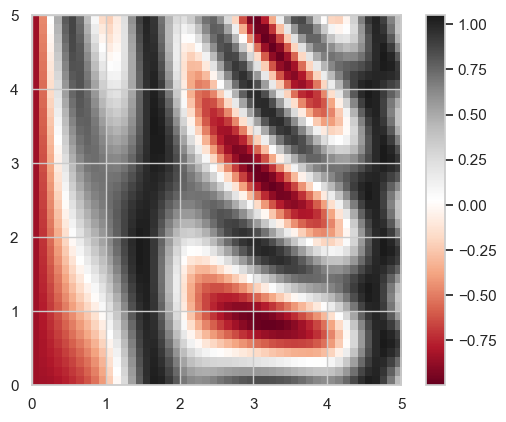

In [ ]:
# try to make it continue
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()

### Histograms,Binnings,and Density
usually for dataset, we need to see the distribution of some data,thus we can use so kind of histograms to work it out

(array([0.0088379 , 0.00441895, 0.01767581, 0.02651371, 0.03977057,
        0.09279799, 0.14582541, 0.15466331, 0.22094758, 0.22094758,
        0.34467823, 0.36677299, 0.43747622, 0.3932867 , 0.45073307,
        0.36235404, 0.28281291, 0.19885283, 0.25188025, 0.1193117 ,
        0.08396008, 0.08396008, 0.04860847, 0.02651371, 0.02209476,
        0.00441895, 0.00441895, 0.        , 0.        , 0.00441895]),
 array([-3.01099058, -2.78469256, -2.55839455, -2.33209653, -2.10579852,
        -1.8795005 , -1.65320248, -1.42690447, -1.20060645, -0.97430843,
        -0.74801042, -0.5217124 , -0.29541439, -0.06911637,  0.15718165,
         0.38347966,  0.60977768,  0.8360757 ,  1.06237371,  1.28867173,
         1.51496974,  1.74126776,  1.96756578,  2.19386379,  2.42016181,
         2.64645983,  2.87275784,  3.09905586,  3.32535387,  3.55165189,
         3.77794991]),
 [<matplotlib.patches.Polygon at 0x2335fc9d6a0>])

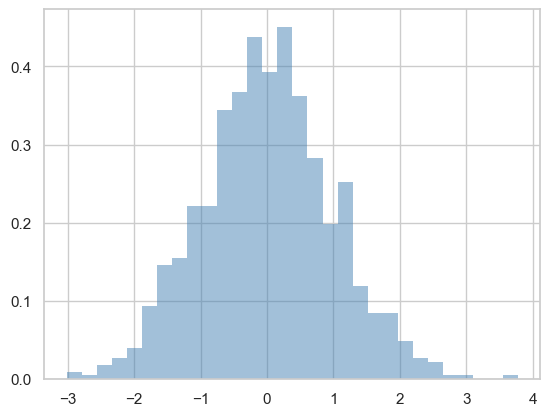

In [ ]:
data = np.random.randn(1000)
plt.hist(data, bins=30, density=True, alpha=0.5,
         histtype='stepfilled', color='steelblue',
         edgecolor='none')
# divide data to 30 part,every part show the possible density,the transparency is 0.5(the other 3 is the form of graph)

[ 43 329 481 139   8]


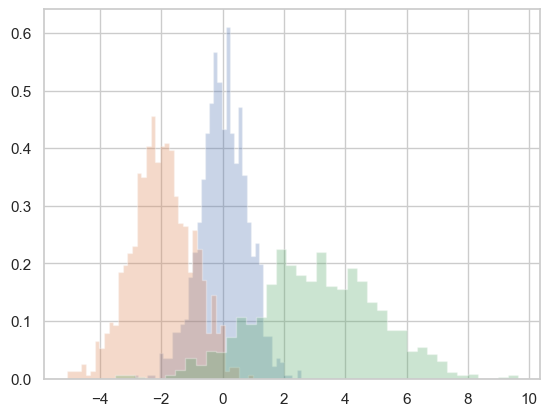

In [38]:
# more graph : use a dict to restore the feature of graph
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, density=True, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs)
counts, bin_edges = np.histogram(data, bins=5)
print(counts) # show the feature of histogram

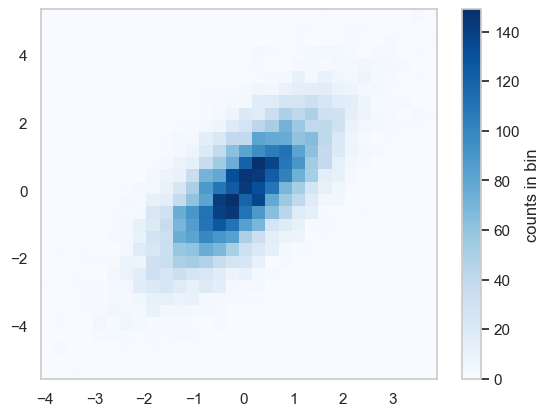

In [39]:
# 2-dimensional histograms and binnings
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')
counts, xedges, yedges = np.histogram2d(x, y, bins=30) # ways to get numeral data

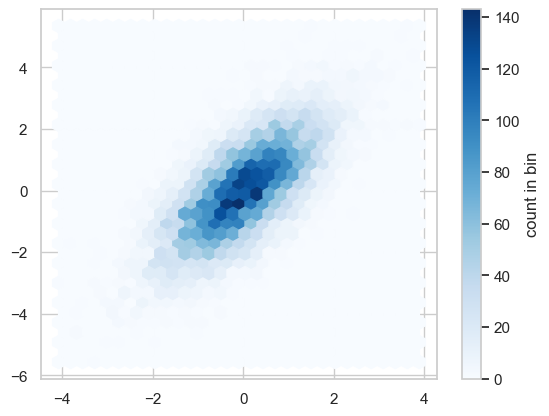

In [40]:
# hexagon kind of 2-dimensional
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

### Customizing Plot Legends
ways to beautify the graph

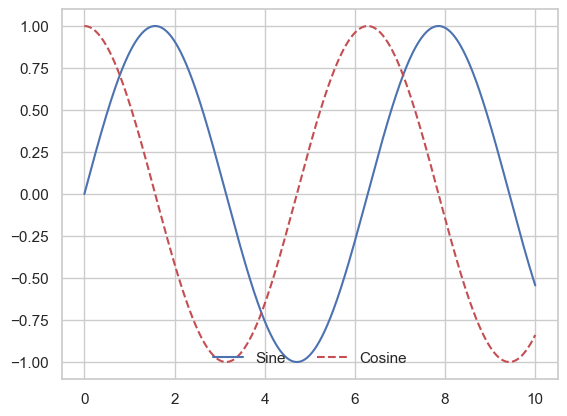

In [ ]:
x = np.linspace(0, 10, 1000)
fig, ax = plt.subplots()
ax.plot(x, np.sin(x), '-b', label='Sine')
ax.plot(x, np.cos(x), '--r', label='Cosine')
ax.legend(frameon=False, loc='lower center', ncol=2) # no frame,2 legend for one row

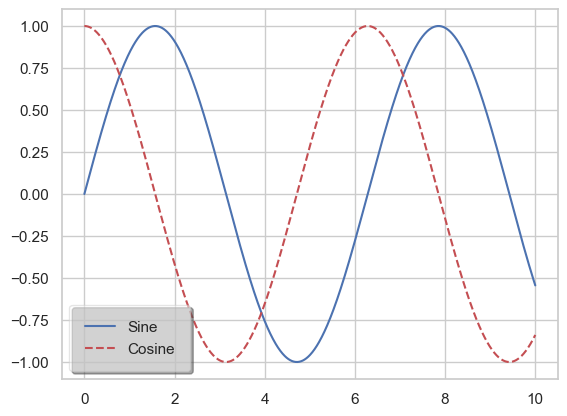

In [ ]:
ax.legend(fancybox=True, framealpha=0.5, shadow=True, borderpad=1) # round widged,shadow
fig

### colorbar
we usually use `plt.imshow(...,cmap='...')`   
as for `cmap` value,we have 3 kinds:
> - *Sequential colormaps*: These are made up of one continuous sequence of colors (e.g., ``binary`` or ``viridis``).
> - *Divergent colormaps*: These usually contain two distinct colors, which show positive and negative deviations from a mean (e.g., ``RdBu`` or ``PuOr``).
> - *Qualitative colormaps*: these mix colors with no particular sequence (e.g., ``rainbow`` or ``jet``).

### Multiple Subplots
draw many different plots at a time

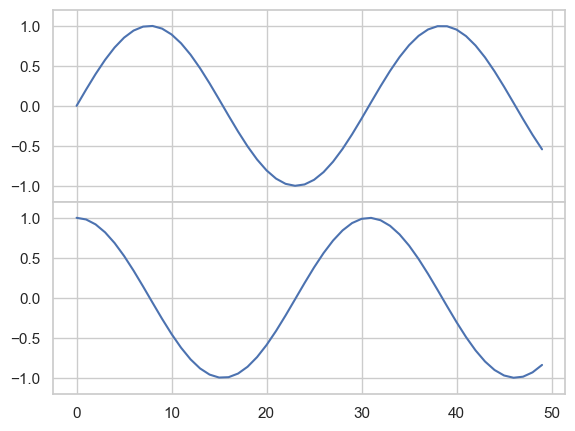

In [ ]:
fig = plt.figure() # get figure object
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2)) # left 10% bottom 50% wide80% high40%(50+40)
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2)) # left10% bottom10% wide80% high40%(10+40)
x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x))

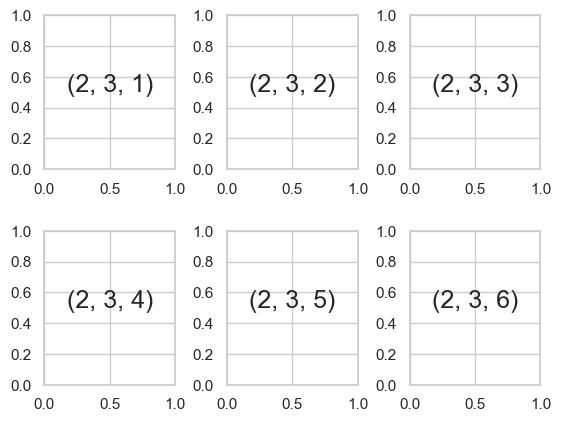

In [ ]:
# object way to deal with it 
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4) # the space between is 0.4 times the origin 
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

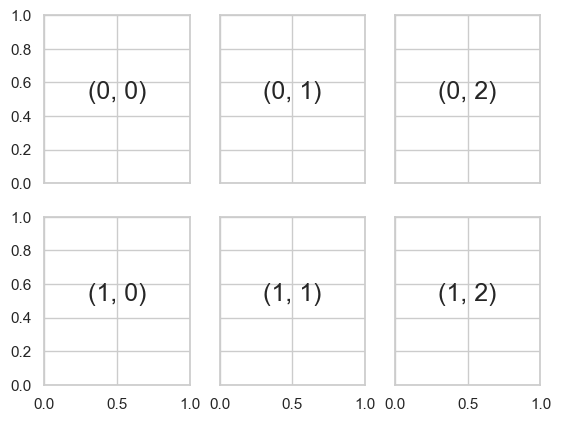

In [49]:
# more easy:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=18, ha='center')

<Axes: >

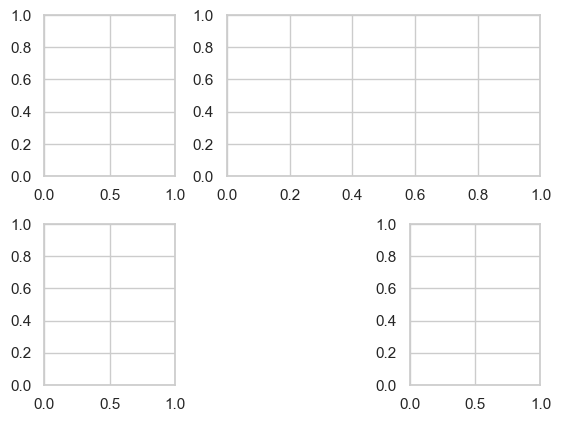

In [52]:
# use grid way: draw the table in advance, and use subplot to demonstrate how to take the place
grid = plt.GridSpec(2, 3, wspace=0.4, hspace=0.3)
plt.subplot(grid[0, 0])
plt.subplot(grid[0, 1:])
plt.subplot(grid[1, :1])
plt.subplot(grid[1, 2])

### Text & Annotation 
add some text in the plt

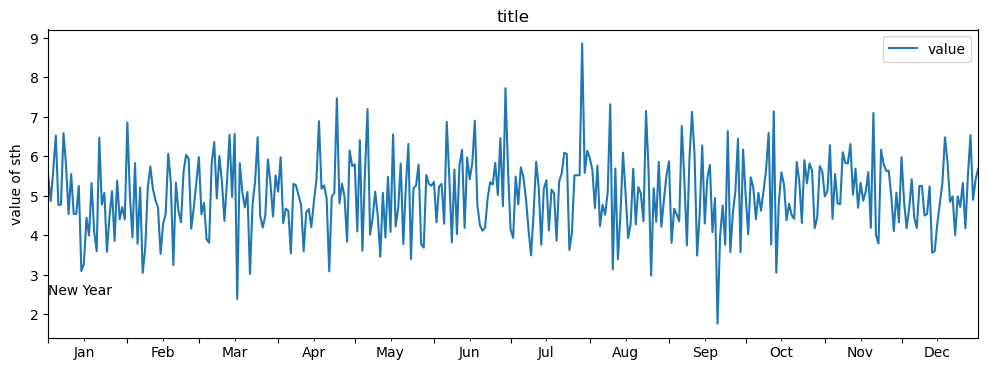

In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
time=pd.date_range('2026-01-01',freq='D',periods=365)
data=pd.DataFrame(np.random.RandomState(42).normal(5,1,365),index=time,columns=['value'])
fig,ax=plt.subplots(figsize=(12, 4))
data.plot(ax=ax)

# add some text
style = dict(size=10, color='gray')
# add value to specific data
ax.text('2026-01-01',data.loc['2026-01-01']['value']-3,"New Year")
# some description
ax.set(title='title',ylabel='value of sth')
# arrangement for the x
ax.xaxis.set_major_locator(mpl.dates.MonthLocator()) #loc the major ticks to the 1st of month
ax.xaxis.set_minor_locator(mpl.dates.MonthLocator(bymonthday=15)) # minor ticks to the 15th
ax.xaxis.set_major_formatter(plt.NullFormatter()) # major tick show nothing
ax.xaxis.set_minor_formatter(mpl.dates.DateFormatter('%h')) #minor ticks show in short form

Text(2026-05-01, 3, 'labor day')

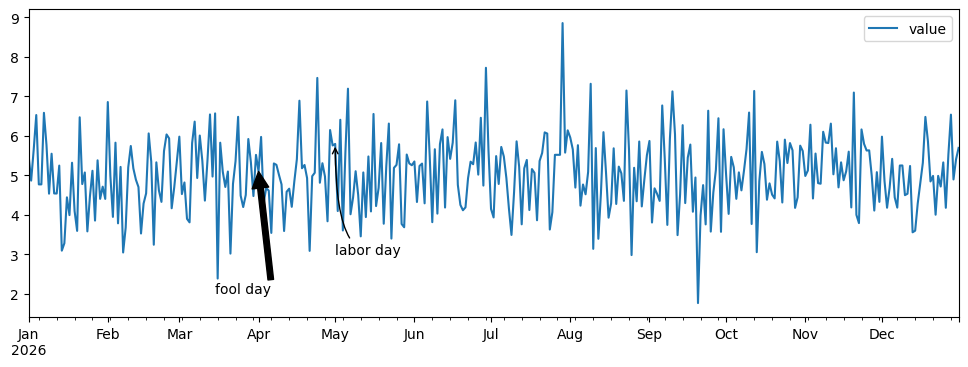

In [22]:
# annotate : arrow
fig, ax = plt.subplots(figsize=(12, 4))
data.plot(ax=ax)
ax.annotate('fool day',xy=('2026-04-01',data.loc['2026-04-01']['value']),xytext=('2026-03-15',2),arrowprops=dict(facecolor='black',shrink=0.001))
ax.annotate('labor day',xy=('2026-05-01',data.loc['2026-05-01']['value']),xytext=('2026-05-01',3),arrowprops=dict(arrowstyle="->",connectionstyle="angle3,angleA=0,angleB=-90"))

Text(0.2, 0.2, '. Figure: (0.2, 0.2)')

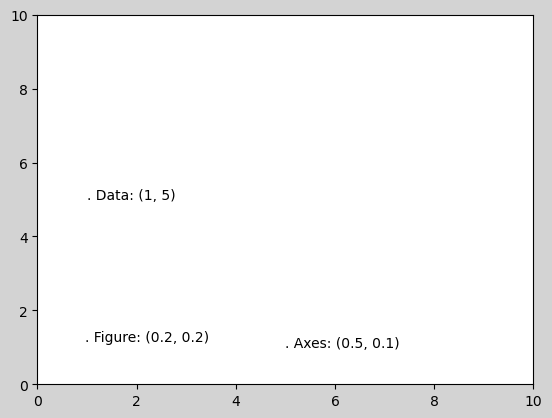

In [ ]:
# something for text arrangement
fig, ax = plt.subplots(facecolor='lightgray')
ax.axis([0, 10, 0, 10])
ax.text(1, 5, ". Data: (1, 5)", transform=ax.transData) # the precise place
ax.text(0.5, 0.1, ". Axes: (0.5, 0.1)", transform=ax.transAxes) # the proportion for axes
ax.text(0.2, 0.2, ". Figure: (0.2, 0.2)", transform=fig.transFigure) # the proportion for fig

### customizing ticks
usually we have major and minor ticks, show the different scope of graph
Locator object        | description
---------------------|-------------
``NullLocator``      | no locator
``FixedLocator``     | fix it
``IndexLocator``     | `IndexLocator(base, offset)` from offset every base step
``LinearLocator``    | evenly distribute
``LogLocator``       | distribute in log form
``MultipleLocator``  | use the value as a cycle
``MaxNLocator``      | max number of locator

Formatter object       | description
----------------------|---------------
``NullFormatter``     | ...
``IndexFormatter``    | ...
``FixedFormatter``    | ...
``FuncFormatter``     | use functions 
``FormatStrFormatter``| use format string

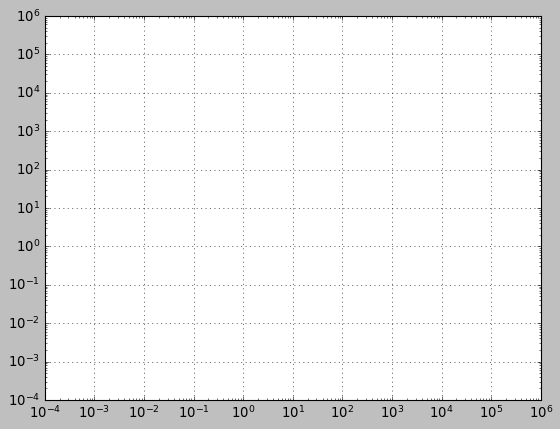

In [ ]:
plt.style.use('classic')
ax = plt.axes(xscale='log', yscale='log', xlim=[10e-5, 10e5], ylim=[10e-5, 10e5]) # scale is how we arrange the axes, lim is how long is the axis
ax.grid()

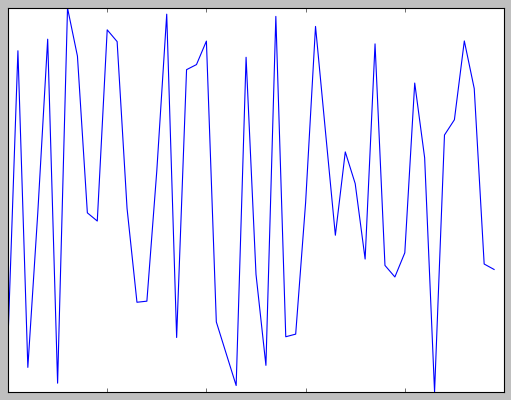

In [29]:
ax = plt.axes()
ax.plot(np.random.rand(50))
# use locator to hide the ticks,and formatter to show the content
ax.yaxis.set_major_locator(plt.NullLocator()) # no major ticks
ax.xaxis.set_major_formatter(plt.NullFormatter()) # major ticks show nothing

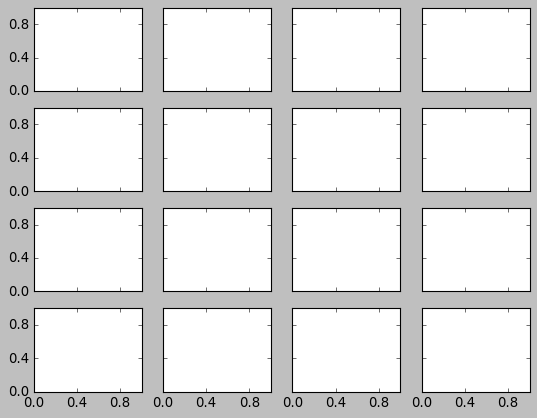

In [30]:
fig, ax = plt.subplots(4, 4, sharex=True, sharey=True)
# set the max locator number
for axi in ax.flat:
    axi.xaxis.set_major_locator(plt.MaxNLocator(3))
    axi.yaxis.set_major_locator(plt.MaxNLocator(3))

### Configurations
as for graphic style we consider:
`ggplot`,`bmh`,`seaborn`

(array([ 15.,  30.,  93., 186., 266., 234., 120.,  45.,   9.,   2.]),
 array([-3.0905284 , -2.42457929, -1.75863018, -1.09268108, -0.42673197,
         0.23921714,  0.90516625,  1.57111536,  2.23706447,  2.90301358,
         3.56896269]),
 <BarContainer object of 10 artists>)

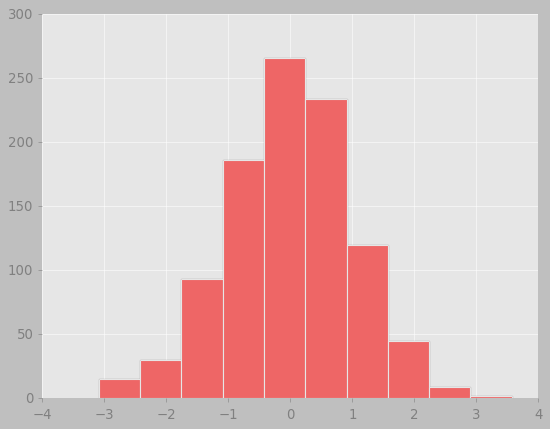

In [ ]:
x = np.random.randn(1000)
# for axes's color,we set the label below graph
ax = plt.axes(facecolor='#E6E6E6')
ax.set_axisbelow(True)
# the graph use white grid
plt.grid(color='w', linestyle='solid')
# hide the border line
for spine in ax.spines.values():
    spine.set_visible(False)
# only keep the tick on the bottom and left
ax.xaxis.tick_bottom()
ax.yaxis.tick_left()
# set the color of tick and labels gray
ax.tick_params(colors='gray', direction='out')
for tick in ax.get_xticklabels():
    tick.set_color('gray')
for tick in ax.get_yticklabels():
    tick.set_color('gray')
plt.hist(x)
# set the hist's edge and filling
ax.hist(x, edgecolor='#E6E6E6', color='#EE6666')

### 3-dimensional plotting

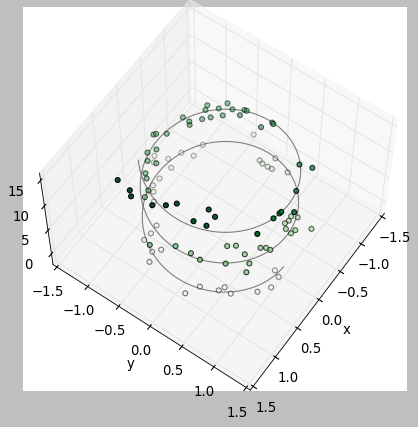

In [ ]:
from mpl_toolkits import mplot3d
fig = plt.figure()
ax = plt.axes(projection='3d')
zline = np.linspace(0, 15, 1000)
xline = np.sin(zline)
yline = np.cos(zline)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.plot3D(xline, yline, zline, 'gray') # draw the line
zdata = 15 * np.random.random(100)
xdata = np.sin(zdata) + 0.1 * np.random.randn(100)
ydata = np.cos(zdata) + 0.1 * np.random.randn(100)
ax.scatter3D(xdata, ydata, zdata, c=zdata, cmap='Greens') # draw the scatter,use z to decide the color
ax.view_init(60, 35) # customize the view angel

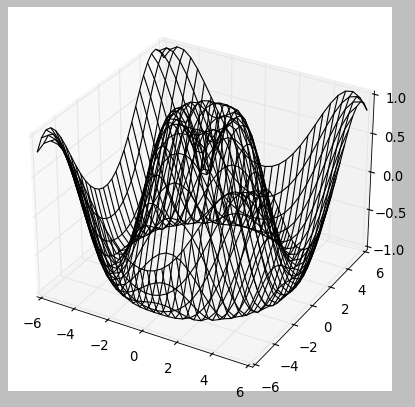

In [39]:
def f(x, y):
    return np.sin(np.sqrt(x ** 2 + y ** 2))
x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_wireframe(X, Y, Z, color='black')

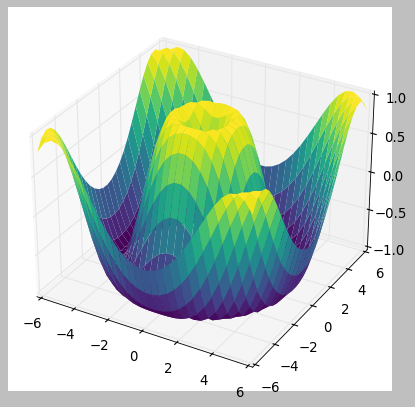

In [40]:
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')

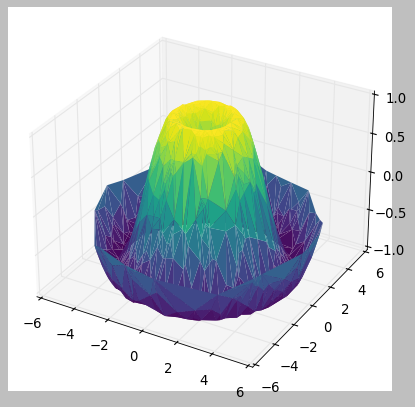

In [ ]:
# use one dimensional data to construct triangulation
theta = 2 * np.pi * np.random.random(1000)
r = 6 * np.random.random(1000)
x = np.ravel(r * np.sin(theta))
y = np.ravel(r * np.cos(theta))
z = f(x, y)
ax = plt.axes(projection='3d')
ax.plot_trisurf(x, y, z,
                cmap='viridis', edgecolor='none')

### Geographic data
usually we use different projections to fit different requirement   
but we cant get the basemap, so skip it.

In [ ]:
import os
os.environ['PROJ_LIB']=os.environ['HOME'] + '/anaconda3/share/proj/' # 如果你的anaconda安装目录不在这里，你可能需要修改
from mpl_toolkits.basemap import Basemap

### visualization with Seaborn
a better choice for pandas,better fit,better taste

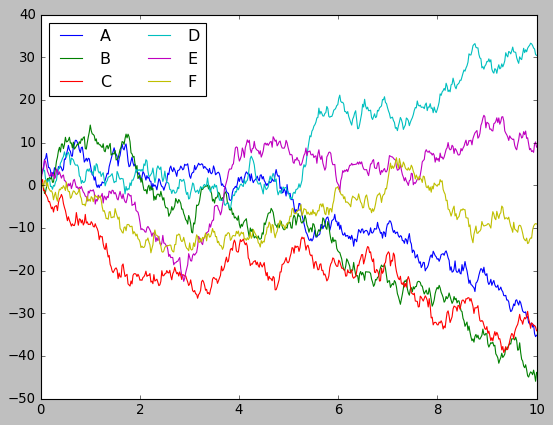

In [1]:
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline
import numpy as np
import pandas as pd
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 500)
y = np.cumsum(rng.randn(500, 6), 0)
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left')

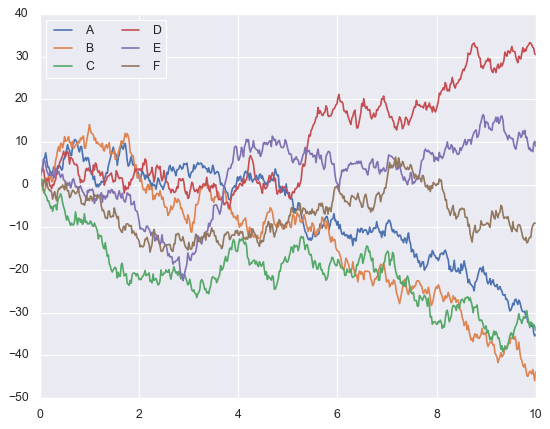

In [ ]:
# with the same code, seaborn have better taste
import seaborn as sns
sns.set_theme()
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left')

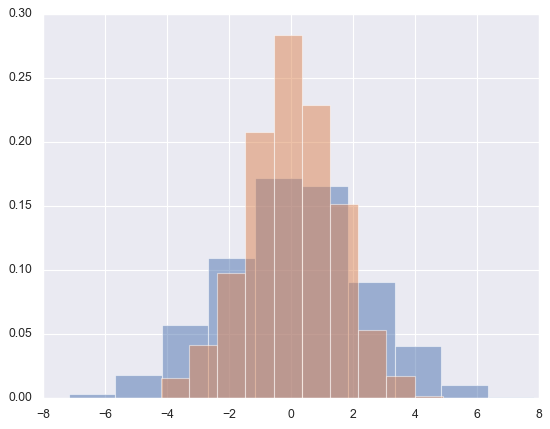

In [3]:
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)
data = pd.DataFrame(data, columns=['x', 'y'])

for col in 'xy':
    plt.hist(data[col], density=True, alpha=0.5)

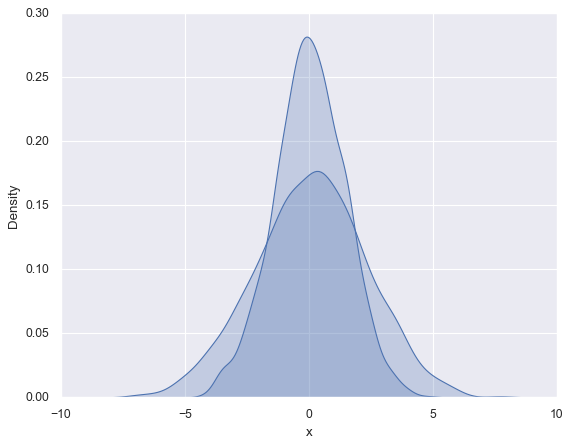

In [5]:
for col in 'xy':
    sns.kdeplot(data[col], fill=True)

<Axes: xlabel='x', ylabel='Count'>

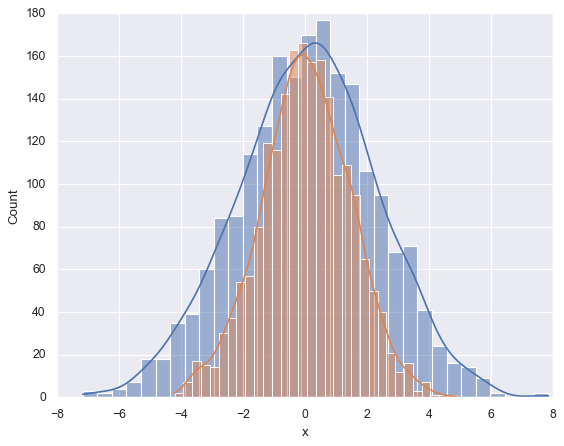

In [6]:
sns.histplot(data['x'], kde=True)
sns.histplot(data['y'], kde=True)

<Axes: xlabel='x', ylabel='y'>

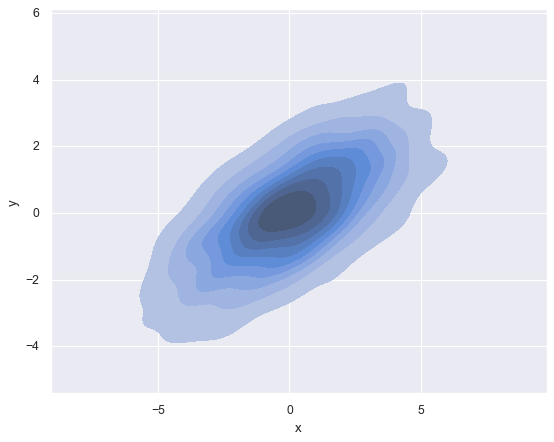

In [11]:
sns.kdeplot(data=data, fill=True, x='x', y='y')

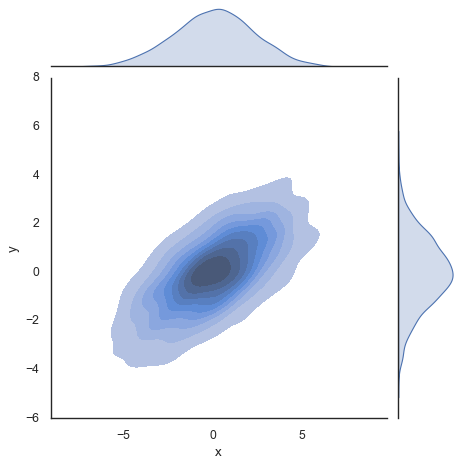

In [12]:
with sns.axes_style('white'):
    sns.jointplot(data=data, x='x', y='y',fill=True,  kind='kde');

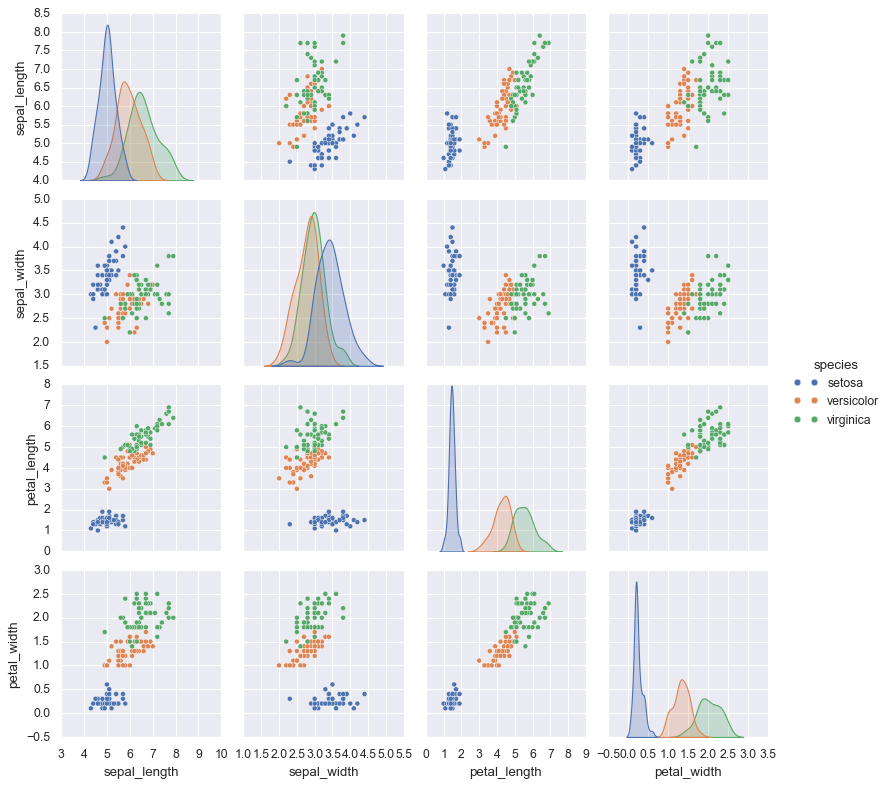

In [13]:
# pairplot: show the relationship between different columns
iris = sns.load_dataset("iris")
iris.head()
sns.pairplot(iris, hue='species', height=2.5)

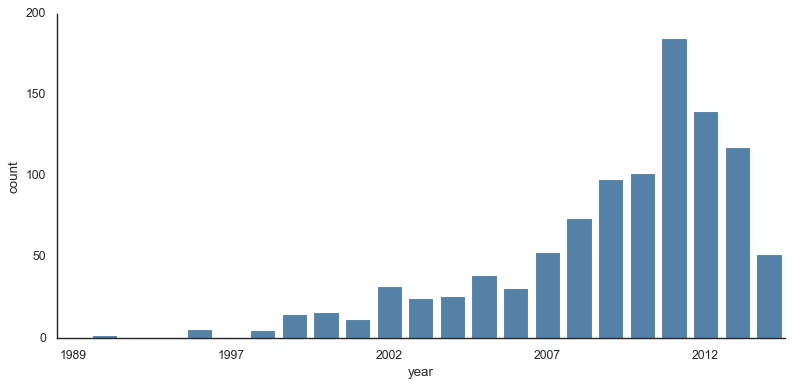

In [ ]:
# bar plot: show the change of data
planets = sns.load_dataset('planets')
with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=2,
                       kind="count", color='steelblue')
    g.set_xticklabels(step=5)

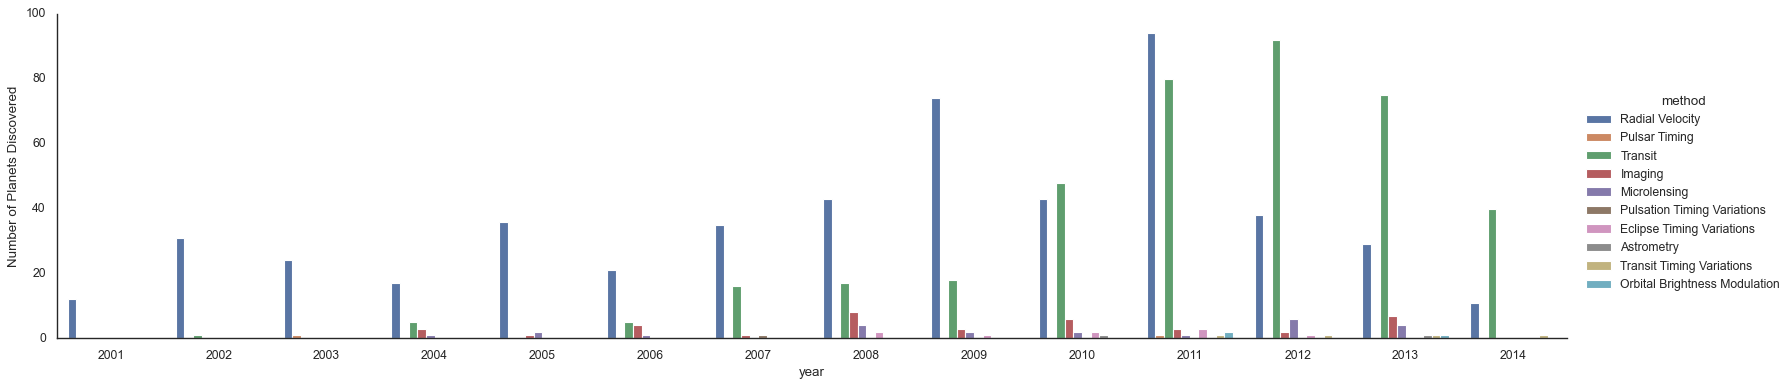

In [19]:
with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=4.0, kind='count',
                       hue='method', order=range(2001, 2015))
    g.set_ylabels('Number of Planets Discovered')

## Summary for Matplotlib
`Matplotlib` is a useful tool for visualization, usually we think about how to draw the graph and how to decorate it.
1. initialize: usually we have 2 kinds of methods : matlab(more precise),object(used for complex stuff)    
usually we use `fig, ax = plt.subplots()` to initial the graph,then we use `ax.` or `plt` to add feature the the `fig` and finally use `fig` to show it in IPython or `fig.savefig('...')` to save it locally
2. generate: usually we use `ax.` or `plt.` + `plot` or `hist()` ect. and the argument inside to draw the graph
3. decorate: usually we can decorate the `axes`,`ticks`,`grid`,`background` ect.(look through the doc)
4. exploration : we can use extensions to work out more stuff